# Seren Pretrain Trace EDA for Quantum/QUBO Instance Design

This notebook analyzes only **Pretrain** jobs from the Seren trace. The goal is to understand how real LLM pretraining workloads can be converted into reduced scheduling instances for MILP, QUBO, D-Wave, tensor-network, and other quantum-inspired experiments.

The notebook compares two pretraining subsets:

- **All Pretrain jobs**: every job labeled `Pretrain`, regardless of final state.
- **Completed Pretrain jobs**: only `Pretrain` jobs with state `COMPLETED`, used as the cleanest proxy for actual completed workload demand.

Questions covered here:

- How large are Seren Pretrain GPU requirements?
- How long are Seren Pretrain jobs, and how many fit below one hour?
- How does the confirmed Seren cluster capacity compare with observed Pretrain demand?
- Should we represent GPU demand with raw GPUs, nodes, or coarse GPU blocks?
- How many Pretrain jobs arrive per day and per hour?
- What hourly energy profile does the historical Pretrain schedule imply?
- How can we generate reusable scheduling instances from these traces?

The trace does not provide optimization-ready deadlines or renewable energy data. Therefore, generated instances combine real job size, duration, and arrival patterns with controlled scheduling windows and synthetic energy inputs.


In [1]:
from __future__ import annotations

import json
from math import ceil, floor, log2
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

TRACE_PATH = Path("/Users/juanparrado/Downloads/trace_seren.csv")
OUTPUT_INSTANCE_DIR = Path("../data/instances/seren_pretrain").resolve()

TOTAL_GPUS = 2288
TOTAL_NODES = 286
GPUS_PER_NODE = 8
CPU_THREADS_PER_NODE = 128
TOTAL_CPU_THREADS = TOTAL_NODES * CPU_THREADS_PER_NODE
GPU_TYPE = "NVIDIA A100-SXM 80GB"
PREFERRED_QUBO_BLOCK_GPUS = 96
BLOCK_GPU_OPTIONS = [32, 64, 96, 128, 256]
MAX_INSTANCE_DURATION_HOURS = 10.0

GPU_TDP_KW = 0.4
SEREN_PUE = 1.25
A100_DATASHEET_URL = "https://www.nvidia.com/content/dam/en-zz/Solutions/Data-Center/a100/pdf/nvidia-a100-datasheet-nvidia-us-2188504-web.pdf"

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


## 1. Load and Prepare Pretrain Jobs

The trace timestamps are parsed as timezone-aware datetimes. The `duration` column is interpreted as seconds and converted to hours.

All analysis below filters the raw trace to `type == "Pretrain"`. When relevant, plots compare all Pretrain jobs against completed Pretrain jobs.


In [2]:
raw = pd.read_csv(TRACE_PATH)

# Keep only Pretrain rows for this notebook.
df = raw[raw["type"] == "Pretrain"].copy()

for column in ["submit_time", "start_time", "end_time"]:
    df[column] = pd.to_datetime(df[column], utc=True, errors="coerce")

df["duration_hours"] = df["duration"] / 3600.0
df["submit_day"] = df["submit_time"].dt.floor("D")
df["submit_hour"] = df["submit_time"].dt.hour
df["submit_date"] = df["submit_time"].dt.date
df["node_units"] = np.ceil(df["gpu_num"] / GPUS_PER_NODE).astype(int)

pretrain = df.copy()
pretrain_completed = df[df["state"] == "COMPLETED"].copy()

pretrain.shape, pretrain_completed.shape, pretrain.head()


((4026, 18),
 (971, 18),
       job_id   user  node_num  gpu_num  cpu_num      type   state               submit_time                start_time                  end_time  duration  queue  gpu_time  \
 338  5786235  u8742        32      256      256  Pretrain  FAILED 2023-03-01 17:18:00+00:00 2023-03-01 17:18:14+00:00 2023-03-01 17:20:13+00:00       119     14   30464.0   
 339  5786237  u8742        32      256      256  Pretrain  FAILED 2023-03-01 17:20:50+00:00 2023-03-01 17:20:55+00:00 2023-03-01 17:22:54+00:00       119      5   30464.0   
 340  5786239  u8742        32      256      256  Pretrain  FAILED 2023-03-01 17:23:03+00:00 2023-03-01 17:23:14+00:00 2023-03-01 17:25:13+00:00       119     11   30464.0   
 341  5786251  u8742        16      128      128  Pretrain  FAILED 2023-03-01 17:26:02+00:00 2023-03-01 17:26:15+00:00 2023-03-01 17:27:54+00:00        99     13   12672.0   
 342  5786252  u8742        16      128      128  Pretrain  FAILED 2023-03-01 17:28:05+00:00 2023-03

In [3]:
summary = pd.DataFrame({
    "subset": ["pretrain_all", "pretrain_completed"],
    "jobs": [len(pretrain), len(pretrain_completed)],
    "start_date": [pretrain["submit_time"].min(), pretrain_completed["submit_time"].min()],
    "end_date": [pretrain["submit_time"].max(), pretrain_completed["submit_time"].max()],
    "mean_gpu_num": [pretrain["gpu_num"].mean(), pretrain_completed["gpu_num"].mean()],
    "median_gpu_num": [pretrain["gpu_num"].median(), pretrain_completed["gpu_num"].median()],
    "mean_duration_hours": [pretrain["duration_hours"].mean(), pretrain_completed["duration_hours"].mean()],
    "median_duration_hours": [pretrain["duration_hours"].median(), pretrain_completed["duration_hours"].median()],
})
summary.round(4)


,subset,jobs,start_date,end_date,mean_gpu_num,median_gpu_num,mean_duration_hours,median_duration_hours
0,pretrain_all,4026,2023-03-01 17:18:00+00:00,2023-08-16 07:53:02+00:00,243.1316,128.0,3.8878,0.0847
1,pretrain_completed,971,2023-03-01 19:23:19+00:00,2023-08-15 07:20:45+00:00,222.0144,128.0,1.4763,0.0178


In [4]:
pretrain_state_summary = (
    pretrain["state"]
    .value_counts()
    .rename_axis("state")
    .reset_index(name="jobs")
)
pretrain_state_summary["share"] = pretrain_state_summary["jobs"] / pretrain_state_summary["jobs"].sum()
pretrain_state_summary


,state,jobs,share
0,CANCELLED,2459,0.610780
1,COMPLETED,971,0.241182
2,FAILED,518,0.128664
3,PREEMPTED,41,0.010184
4,NODE_FAIL,27,0.006706
5,TIMEOUT,10,0.002484


## 2. Pretrain GPU Requirement Analysis

Seren Pretrain jobs are large enough to create real packing conflicts. The relevant question for QUBO is the resource unit:

- **Raw GPUs** preserve exact demand but increase slack encoding size.
- **Node units** are physically interpretable if one node has 8 GPUs.
- **GPU blocks** reduce the QUBO size, but they are a quantum abstraction rather than an operational unit.


In [5]:
def gpu_distribution(frame: pd.DataFrame, label: str) -> pd.Series:
    """Summarize Pretrain GPU and node demand distribution."""

    gpu_values = frame["gpu_num"]
    node_values = np.ceil(frame["gpu_num"] / GPUS_PER_NODE)
    return pd.Series({
        "label": label,
        "jobs": len(frame),
        "gpu_min": gpu_values.min(),
        "gpu_p10": gpu_values.quantile(0.10),
        "gpu_p25": gpu_values.quantile(0.25),
        "gpu_median": gpu_values.quantile(0.50),
        "gpu_mean": gpu_values.mean(),
        "gpu_p75": gpu_values.quantile(0.75),
        "gpu_p90": gpu_values.quantile(0.90),
        "gpu_p95": gpu_values.quantile(0.95),
        "gpu_p99": gpu_values.quantile(0.99),
        "gpu_max": gpu_values.max(),
        "node_median": node_values.median(),
        "node_mean": node_values.mean(),
        "node_max": node_values.max(),
    })

frames = {
    "pretrain_all": pretrain,
    "pretrain_completed": pretrain_completed,
}

gpu_summary = pd.DataFrame([gpu_distribution(frame, label) for label, frame in frames.items()])
gpu_summary.round(4)


,label,jobs,gpu_min,gpu_p10,gpu_p25,gpu_median,gpu_mean,gpu_p75,gpu_p90,gpu_p95,gpu_p99,gpu_max,node_median,node_mean,node_max
0,pretrain_all,4026,40,64.0,64.0,128.0,243.1316,256.0,768.0,960.0,1024.0,1024,16.0,30.3915,128.0
1,pretrain_completed,971,40,56.0,64.0,128.0,222.0144,256.0,512.0,768.0,1024.0,1024,16.0,27.7518,128.0


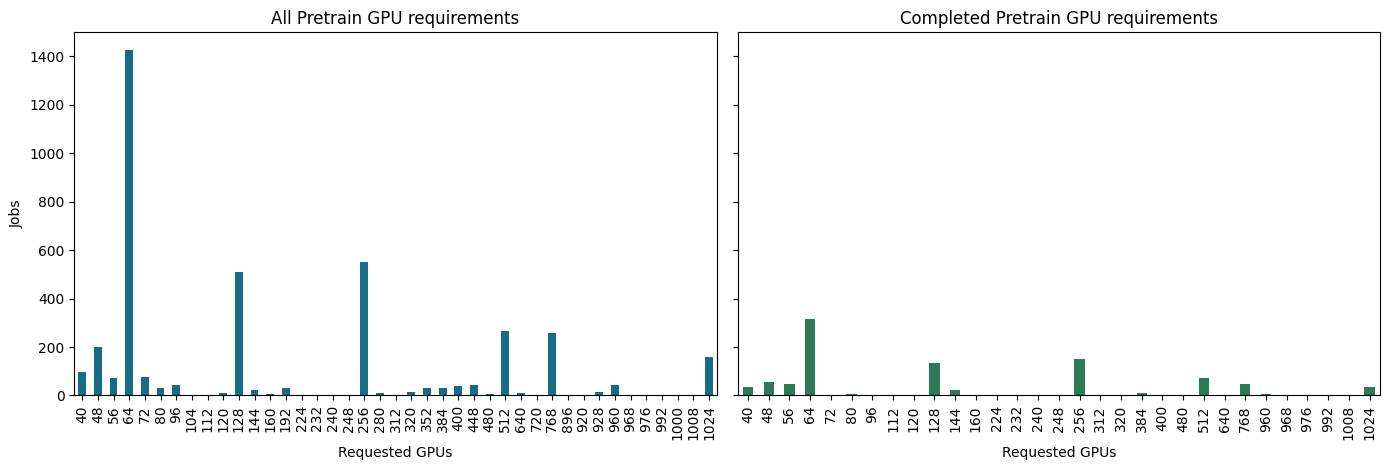

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)

pretrain["gpu_num"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#176b87")
axes[0].set_title("All Pretrain GPU requirements")
axes[0].set_xlabel("Requested GPUs")
axes[0].set_ylabel("Jobs")

pretrain_completed["gpu_num"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#2c7a57")
axes[1].set_title("Completed Pretrain GPU requirements")
axes[1].set_xlabel("Requested GPUs")
axes[1].set_ylabel("Jobs")

plt.tight_layout()
plt.show()


## 3. Pretrain Duration Distribution

Many Pretrain jobs are short even when GPU demand is large. This matters because time discretization changes the optimization problem:

- with 1-hour slots, every job below one hour becomes a one-slot job;
- with 15-minute slots, the model captures short jobs better but creates more assignment variables;
- long jobs must be controlled explicitly because they can dominate GPU-time and energy.

The generated scheduling instances later filter jobs longer than 10 hours.


In [7]:
def duration_distribution(frame: pd.DataFrame, label: str) -> pd.Series:
    """Summarize Pretrain job duration in hours and threshold shares."""

    values = frame["duration_hours"]
    return pd.Series({
        "subset": label,
        "jobs": len(frame),
        "min_h": values.min(),
        "p10_h": values.quantile(0.10),
        "p25_h": values.quantile(0.25),
        "median_h": values.quantile(0.50),
        "mean_h": values.mean(),
        "p75_h": values.quantile(0.75),
        "p90_h": values.quantile(0.90),
        "p95_h": values.quantile(0.95),
        "p99_h": values.quantile(0.99),
        "max_h": values.max(),
        "share_below_15min": (values < 0.25).mean(),
        "share_below_1h": (values < 1.0).mean(),
        "share_below_or_equal_10h": (values <= MAX_INSTANCE_DURATION_HOURS).mean(),
    })

pretrain_duration_summary = pd.DataFrame([
    duration_distribution(pretrain, "pretrain_all"),
    duration_distribution(pretrain_completed, "pretrain_completed"),
]).round(4)
pretrain_duration_summary


,subset,jobs,min_h,p10_h,p25_h,median_h,mean_h,p75_h,p90_h,p95_h,p99_h,max_h,share_below_15min,share_below_1h,share_below_or_equal_10h
0,pretrain_all,4026,0.0,0.0014,0.0139,0.0847,3.8878,0.3219,7.0771,20.4053,80.5987,335.1736,0.7131,0.8351,0.9146
1,pretrain_completed,971,0.0,0.0003,0.0039,0.0178,1.4763,0.0888,0.4747,8.2247,36.5398,146.6433,0.8764,0.9197,0.9537


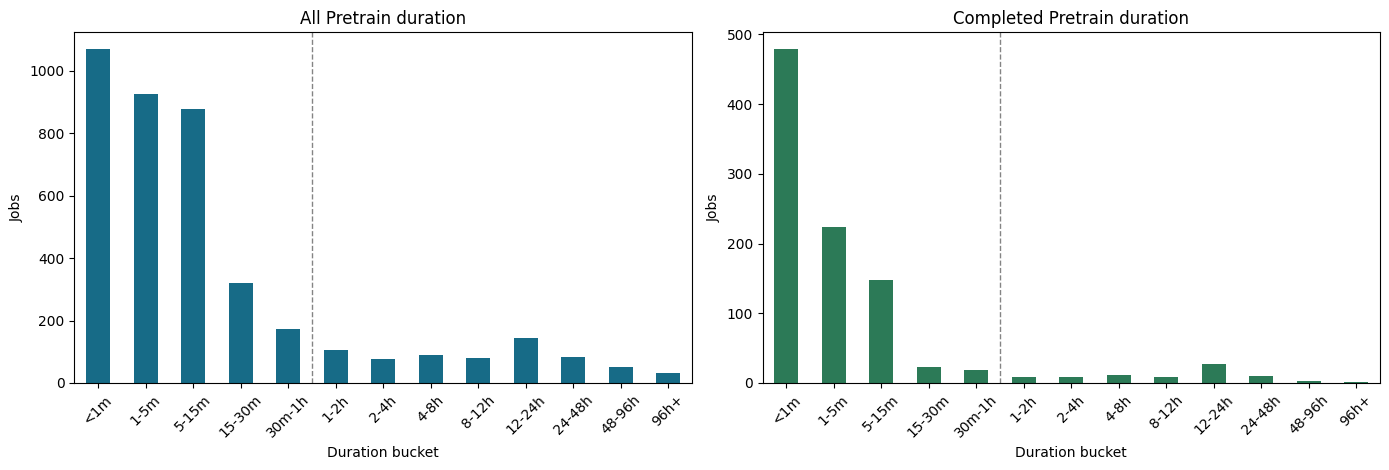

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

bins = np.array([0, 1/60, 5/60, 15/60, 30/60, 1, 2, 4, 8, 12, 24, 48, 96, 400])
labels = ["<1m", "1-5m", "5-15m", "15-30m", "30m-1h", "1-2h", "2-4h", "4-8h", "8-12h", "12-24h", "24-48h", "48-96h", "96h+"]

for ax, frame, title, color in [
    (axes[0], pretrain, "All Pretrain duration", "#176b87"),
    (axes[1], pretrain_completed, "Completed Pretrain duration", "#2c7a57"),
]:
    bucket = pd.cut(frame["duration_hours"], bins=bins, labels=labels, right=False, include_lowest=True)
    bucket.value_counts().reindex(labels, fill_value=0).plot(kind="bar", ax=ax, color=color)
    ax.axvline(labels.index("30m-1h") + 0.5, color="#333333", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("Duration bucket")
    ax.set_ylabel("Jobs")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


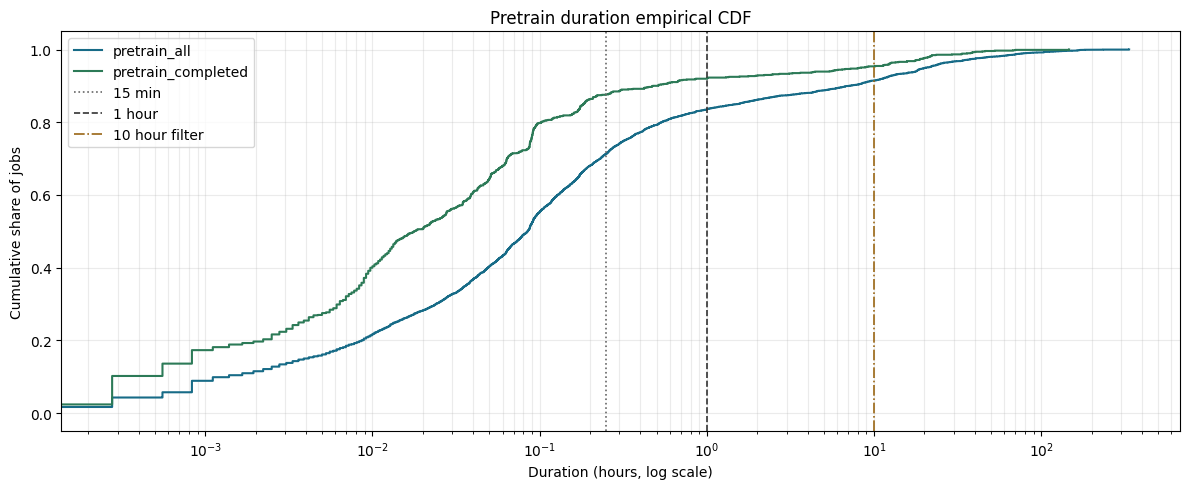

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
for label, frame, color in [
    ("pretrain_all", pretrain, "#176b87"),
    ("pretrain_completed", pretrain_completed, "#2c7a57"),
]:
    values = np.sort(frame["duration_hours"].to_numpy())
    y = np.arange(1, len(values) + 1) / len(values)
    ax.step(values, y, where="post", label=label, color=color)

ax.axvline(0.25, color="#666666", linestyle=":", linewidth=1.2, label="15 min")
ax.axvline(1.0, color="#333333", linestyle="--", linewidth=1.2, label="1 hour")
ax.axvline(MAX_INSTANCE_DURATION_HOURS, color="#9a6615", linestyle="-.", linewidth=1.2, label="10 hour filter")
ax.set_xscale("log")
ax.set_title("Pretrain duration empirical CDF")
ax.set_xlabel("Duration (hours, log scale)")
ax.set_ylabel("Cumulative share of jobs")
ax.grid(alpha=0.25, which="both")
ax.legend()
plt.tight_layout()
plt.show()


In [10]:
slot_duration_impact = []
for slot_minutes in [15, 30, 60]:
    slot_hours = slot_minutes / 60
    for label, frame in [("pretrain_all", pretrain), ("pretrain_completed", pretrain_completed)]:
        rounded_slots = np.ceil(frame["duration_hours"] / slot_hours).astype(int)
        rounded_hours = rounded_slots * slot_hours
        slot_duration_impact.append({
            "subset": label,
            "slot_minutes": slot_minutes,
            "mean_slots_per_job": rounded_slots.mean(),
            "median_slots_per_job": rounded_slots.median(),
            "mean_rounded_duration_h": rounded_hours.mean(),
            "mean_rounding_overstatement_h": (rounded_hours - frame["duration_hours"]).mean(),
            "share_one_slot_jobs": (rounded_slots == 1).mean(),
        })

slot_duration_impact = pd.DataFrame(slot_duration_impact).round(4)
slot_duration_impact


,subset,slot_minutes,mean_slots_per_job,median_slots_per_job,mean_rounded_duration_h,mean_rounding_overstatement_h,share_one_slot_jobs
0,pretrain_all,15,16.2340,1.0,4.0585,0.1706,0.6965
1,pretrain_completed,15,6.6962,1.0,1.6740,0.1978,0.8527
2,pretrain_all,30,8.5243,1.0,4.2622,0.3743,0.7757
3,pretrain_completed,30,3.8043,1.0,1.9022,0.4259,0.8764
4,pretrain_all,60,4.6937,1.0,4.6937,0.8059,0.8184
5,pretrain_completed,60,2.3625,1.0,2.3625,0.8862,0.8960


## 4. Seren Cluster Capacity and Nodes vs Blocks

The Seren hardware configuration is now available, so the notebook uses physical capacity instead of a trace-inferred lower bound:

```text
2,288 NVIDIA A100-SXM 80GB GPUs
286 nodes
8 GPUs per node
128 CPU threads per node
PUE = 1.25
```

We still compute the maximum concurrent Pretrain GPU usage observed in the trace. That value is useful as a historical utilization check, but it is no longer used as cluster capacity.


In [11]:
def max_concurrent_gpu_usage(frame: pd.DataFrame) -> tuple[int, pd.Timestamp]:
    """Compute maximum concurrent GPU usage from historical Pretrain execution intervals."""

    jobs = frame[frame["start_time"].notna() & frame["end_time"].notna() & (frame["end_time"] > frame["start_time"])].copy()
    events = []
    for job in jobs.itertuples(index=False):
        events.append((job.start_time, int(job.gpu_num)))
        events.append((job.end_time, -int(job.gpu_num)))
    events.sort(key=lambda item: (item[0], -item[1]))

    current = 0
    maximum = 0
    maximum_time = pd.NaT
    for timestamp, delta in events:
        current += delta
        if current > maximum:
            maximum = current
            maximum_time = timestamp
    return maximum, maximum_time

max_concurrent_gpus, max_concurrent_time = max_concurrent_gpu_usage(pretrain)

seren_capacity_summary = pd.DataFrame([{
    "physical_total_gpus": TOTAL_GPUS,
    "physical_total_nodes": TOTAL_NODES,
    "gpu_type": GPU_TYPE,
    "gpu_tdp_kw": GPU_TDP_KW,
    "pue": SEREN_PUE,
    "cpu_threads_per_node": CPU_THREADS_PER_NODE,
    "total_cpu_threads": TOTAL_CPU_THREADS,
    "max_concurrent_pretrain_gpus_observed": max_concurrent_gpus,
    "max_concurrent_time": max_concurrent_time,
    "observed_pretrain_gpu_utilization_at_peak": max_concurrent_gpus / TOTAL_GPUS,
}])
seren_capacity_summary


,physical_total_gpus,physical_total_nodes,gpu_type,gpu_tdp_kw,pue,cpu_threads_per_node,total_cpu_threads,max_concurrent_pretrain_gpus_observed,max_concurrent_time,observed_pretrain_gpu_utilization_at_peak
0,2288,286,NVIDIA A100-SXM 80GB,0.4,1.25,128,36608,1952,2023-03-23 08:54:05+00:00,0.853147


In [12]:
def scaled_gpu_report(frame: pd.DataFrame, total_gpus: int, unit_gpu: int, label: str) -> pd.Series:
    """Report capacity and demand after scaling raw GPUs into integer units."""

    demand = np.ceil(frame["gpu_num"] / unit_gpu).astype(int)
    capacity = floor(total_gpus / unit_gpu)
    equivalent_gpu = demand * unit_gpu
    relative_overstatement = (equivalent_gpu - frame["gpu_num"]) / frame["gpu_num"].replace(0, np.nan)
    return pd.Series({
        "unit": label,
        "unit_gpu": unit_gpu,
        "capacity_units": capacity,
        "slack_bits_per_cluster_time": ceil(log2(capacity + 1)) if capacity > 0 else 1,
        "min_demand": demand.min(),
        "median_demand": demand.median(),
        "mean_demand": demand.mean(),
        "max_demand": demand.max(),
        "mean_relative_overstatement": relative_overstatement.mean(),
        "max_relative_overstatement": relative_overstatement.max(),
        "jobs_exceeding_capacity": int((demand > capacity).sum()),
    })

unit_rows = [scaled_gpu_report(pretrain_completed, TOTAL_GPUS, GPUS_PER_NODE, "node: 8 GPUs")]
for unit_gpu in BLOCK_GPU_OPTIONS:
    unit_rows.append(scaled_gpu_report(pretrain_completed, TOTAL_GPUS, unit_gpu, f"block: {unit_gpu} GPUs"))

scaling_summary = pd.DataFrame(unit_rows)
scaling_summary.round(4)


,unit,unit_gpu,capacity_units,slack_bits_per_cluster_time,min_demand,median_demand,mean_demand,max_demand,mean_relative_overstatement,max_relative_overstatement,jobs_exceeding_capacity
0,node: 8 GPUs,8,286,9,5,16.0,27.7518,128,0.0000,0.0000,0
1,block: 32 GPUs,32,71,7,2,4.0,7.0288,32,0.0527,0.6000,0
2,block: 64 GPUs,64,35,6,1,2.0,3.5376,16,0.0631,0.7778,0
3,block: 96 GPUs,96,23,5,1,2.0,2.7240,11,0.4198,1.4000,0
4,block: 128 GPUs,128,17,5,1,1.0,2.0216,8,0.5932,2.2000,0
5,block: 256 GPUs,256,8,4,1,1.0,1.3285,4,1.7892,5.4000,0


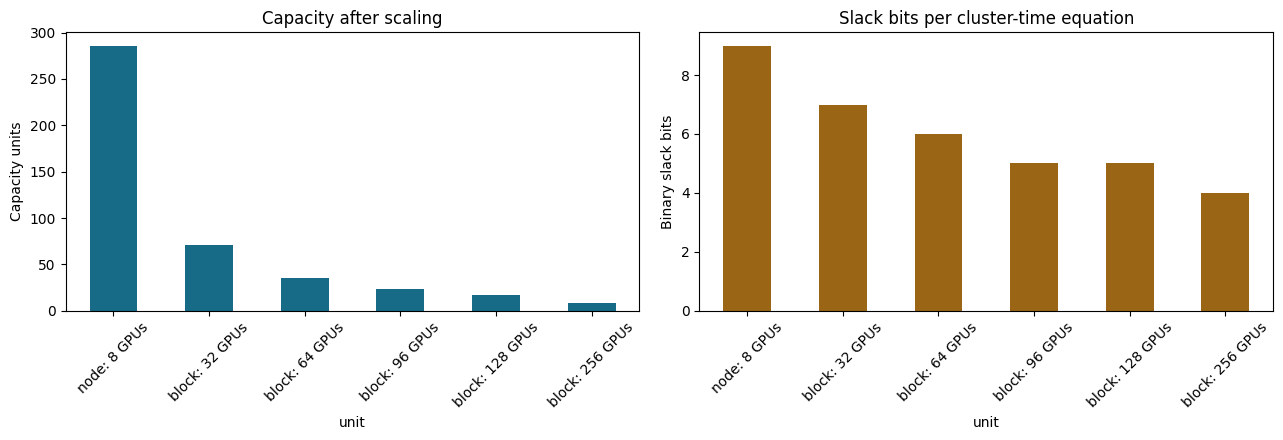

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

scaling_summary.plot(x="unit", y="capacity_units", kind="bar", ax=axes[0], color="#176b87", legend=False)
axes[0].set_title("Capacity after scaling")
axes[0].set_ylabel("Capacity units")
axes[0].tick_params(axis="x", rotation=45)

scaling_summary.plot(x="unit", y="slack_bits_per_cluster_time", kind="bar", ax=axes[1], color="#9a6615", legend=False)
axes[1].set_title("Slack bits per cluster-time equation")
axes[1].set_ylabel("Binary slack bits")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 5. Pretrain Job Arrival Volume by Day and Hour

Arrival intensity determines how many jobs compete inside a rolling scheduling horizon. The daily profile is especially useful for deciding instance sizes: average active day, high-load day, and stress-test day.


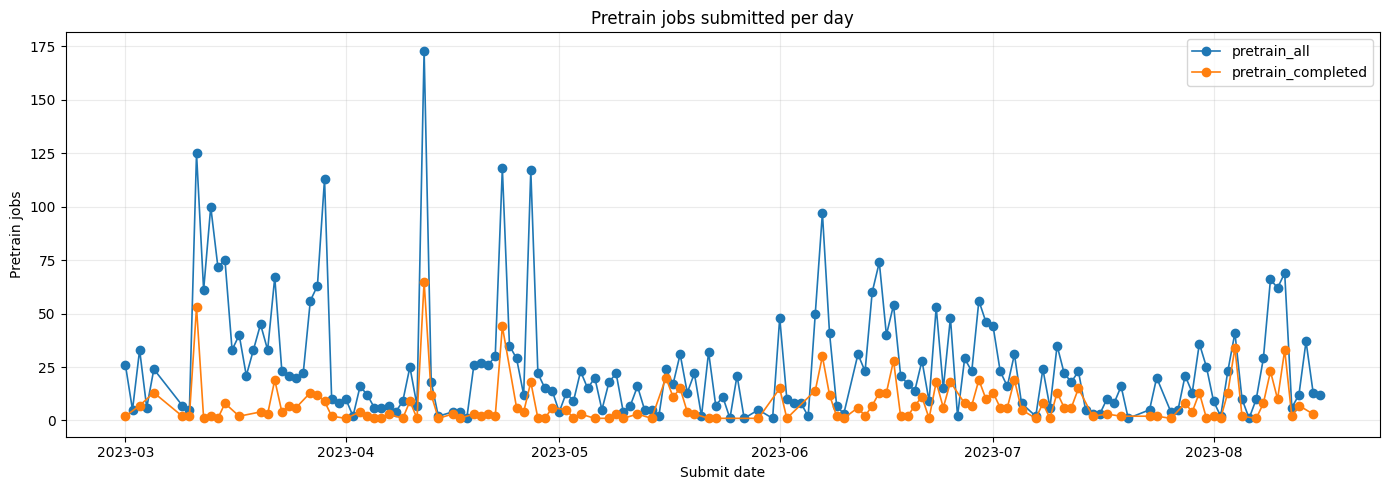

,count,mean,std,min,25%,50%,75%,90%,max
series,,,,,,,,,
pretrain_all,158.0,25.48,27.59,1.0,7.0,18.0,31.75,60.3,173.0
pretrain_completed,123.0,7.89,10.23,1.0,2.0,4.0,11.00,18.0,65.0


In [14]:
def daily_counts(frame: pd.DataFrame, label: str) -> pd.DataFrame:
    """Count submitted jobs by day for one Pretrain subset."""

    out = frame.groupby("submit_date").size().rename("jobs").reset_index()
    out["series"] = label
    return out

daily = pd.concat([
    daily_counts(pretrain, "pretrain_all"),
    daily_counts(pretrain_completed, "pretrain_completed"),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(14, 5))
for label, group in daily.groupby("series"):
    ax.plot(pd.to_datetime(group["submit_date"]), group["jobs"], marker="o", linewidth=1.2, label=label)
ax.set_title("Pretrain jobs submitted per day")
ax.set_xlabel("Submit date")
ax.set_ylabel("Pretrain jobs")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

daily_summary = daily.groupby("series")["jobs"].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(2)
daily_summary


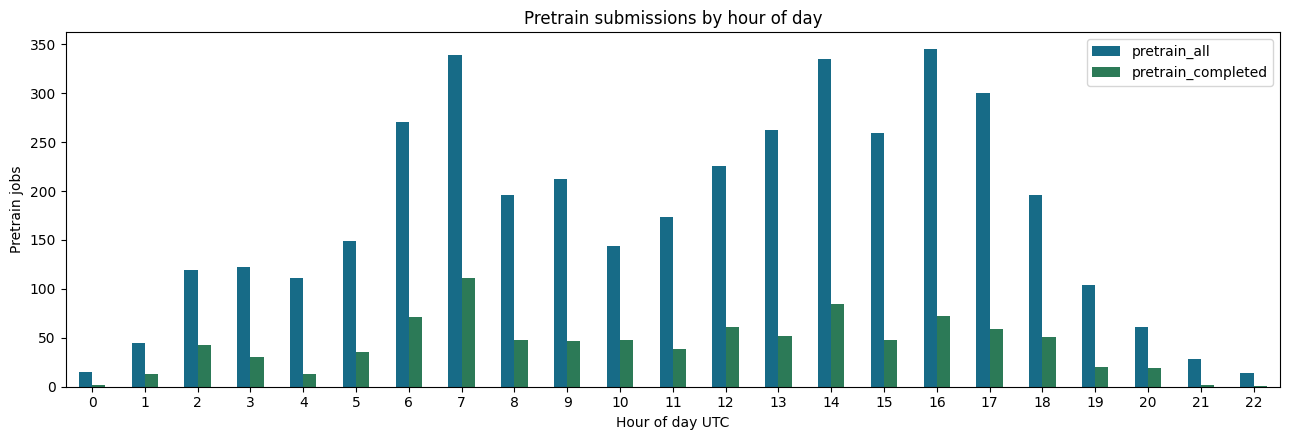

,pretrain_all,pretrain_completed
submit_hour,,
0,15,2
1,45,13
2,119,43
3,122,30
4,111,13
5,149,36
6,271,71
7,339,111
8,196,48


In [15]:
hourly_profile = pd.DataFrame({
    "pretrain_all": pretrain.groupby("submit_hour").size(),
    "pretrain_completed": pretrain_completed.groupby("submit_hour").size(),
}).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(13, 4.5))
hourly_profile.plot(kind="bar", ax=ax, color=["#176b87", "#2c7a57"])
ax.set_title("Pretrain submissions by hour of day")
ax.set_xlabel("Hour of day UTC")
ax.set_ylabel("Pretrain jobs")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

hourly_profile


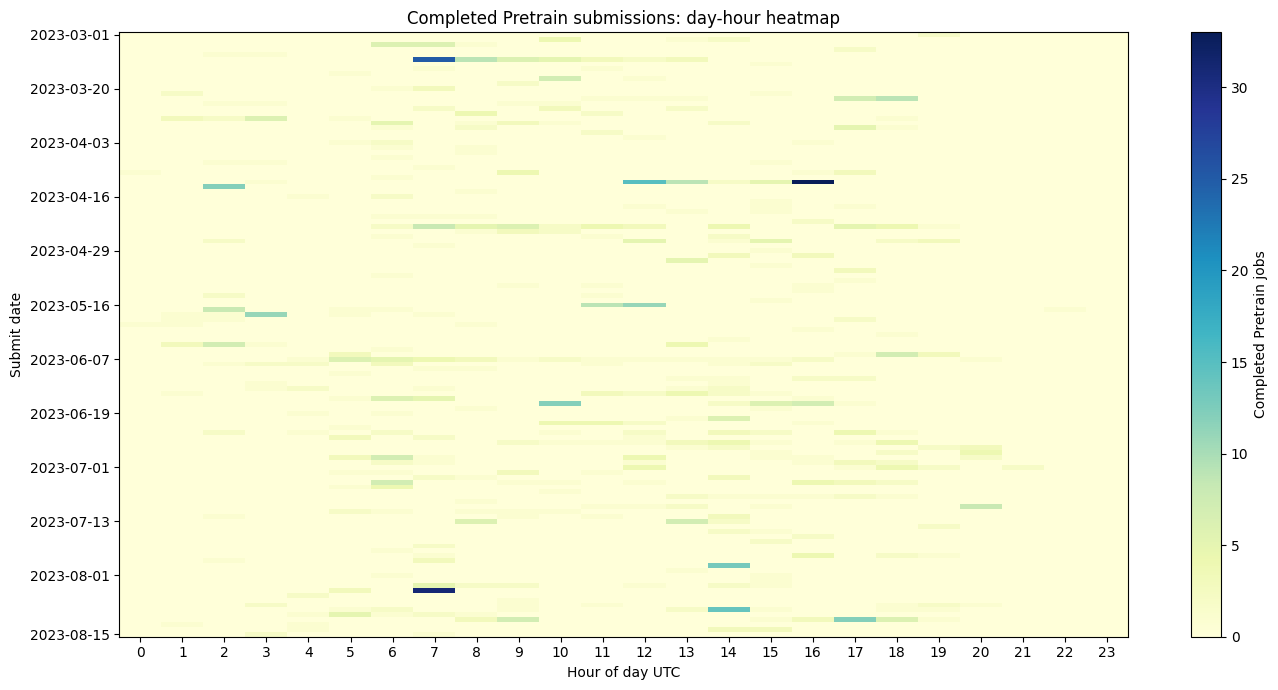

In [16]:
pretrain_completed_heatmap = (
    pretrain_completed
    .groupby(["submit_date", "submit_hour"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range(24), fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(pretrain_completed_heatmap.values, aspect="auto", cmap="YlGnBu")
ax.set_title("Completed Pretrain submissions: day-hour heatmap")
ax.set_xlabel("Hour of day UTC")
ax.set_ylabel("Submit date")
ax.set_xticks(range(24))
y_ticks = np.linspace(0, len(pretrain_completed_heatmap.index) - 1, min(12, len(pretrain_completed_heatmap.index))).astype(int)
ax.set_yticks(y_ticks)
ax.set_yticklabels([str(pretrain_completed_heatmap.index[i]) for i in y_ticks])
fig.colorbar(im, ax=ax, label="Completed Pretrain jobs")
plt.tight_layout()
plt.show()


## 6. Historical Pretrain Energy Consumption per Hour

This section estimates hourly energy consumed by the historical Seren Pretrain schedule.

Assumptions:

- each requested GPU is modeled at the configured `GPU_TDP_KW`;
- hourly IT energy is computed from the overlap between each job execution interval and each hourly bucket;
- facility energy applies constant PUE: `facility_energy = IT_energy * SEREN_PUE`;
- this is an estimate of historical consumption, not an optimized schedule.


In [17]:
def hourly_energy_profile(frame: pd.DataFrame, label: str) -> pd.DataFrame:
    """Estimate hourly GPU and energy consumption from historical execution intervals."""

    rows = []
    jobs = frame.copy()
    jobs = jobs[jobs["start_time"].notna() & jobs["end_time"].notna() & (jobs["end_time"] > jobs["start_time"])]

    if jobs.empty:
        return pd.DataFrame(columns=["hour", "series", "active_gpu_hours", "avg_active_gpus", "it_energy_mwh", "facility_energy_mwh"])

    first_hour = jobs["start_time"].min().floor("h")
    last_hour = jobs["end_time"].max().ceil("h")
    hours = pd.date_range(first_hour, last_hour, freq="h", inclusive="left")

    for hour_start in hours:
        hour_end = hour_start + pd.Timedelta(hours=1)
        active = jobs[(jobs["start_time"] < hour_end) & (jobs["end_time"] > hour_start)]
        gpu_hours = 0.0
        for job in active.itertuples(index=False):
            overlap_start = max(job.start_time, hour_start)
            overlap_end = min(job.end_time, hour_end)
            overlap_hours = (overlap_end - overlap_start).total_seconds() / 3600.0
            gpu_hours += float(job.gpu_num) * overlap_hours

        it_energy_mwh = gpu_hours * GPU_TDP_KW / 1000.0
        rows.append({
            "hour": hour_start,
            "series": label,
            "active_gpu_hours": gpu_hours,
            "avg_active_gpus": gpu_hours,
            "it_energy_mwh": it_energy_mwh,
            "facility_energy_mwh": it_energy_mwh * SEREN_PUE,
        })

    return pd.DataFrame(rows)

energy_hourly = pd.concat([
    hourly_energy_profile(pretrain, "pretrain_all"),
    hourly_energy_profile(pretrain_completed, "pretrain_completed"),
], ignore_index=True)

energy_summary = (
    energy_hourly
    .groupby("series")[["active_gpu_hours", "it_energy_mwh", "facility_energy_mwh"]]
    .agg(["sum", "mean", "max"])
    .round(4)
)
energy_summary


active_gpu_hours                    it_energy_mwh                 facility_energy_mwh                
                                sum      mean      max           sum    mean     max                 sum    mean     max
series                                                                                                                  
pretrain_all           3.910073e+06  944.9187  1952.00     1564.0294  0.3780  0.7808           1955.0367  0.4725  0.9760
pretrain_completed     4.773738e+05  119.4330  1283.32      190.9495  0.0478  0.5133            238.6869  0.0597  0.6417

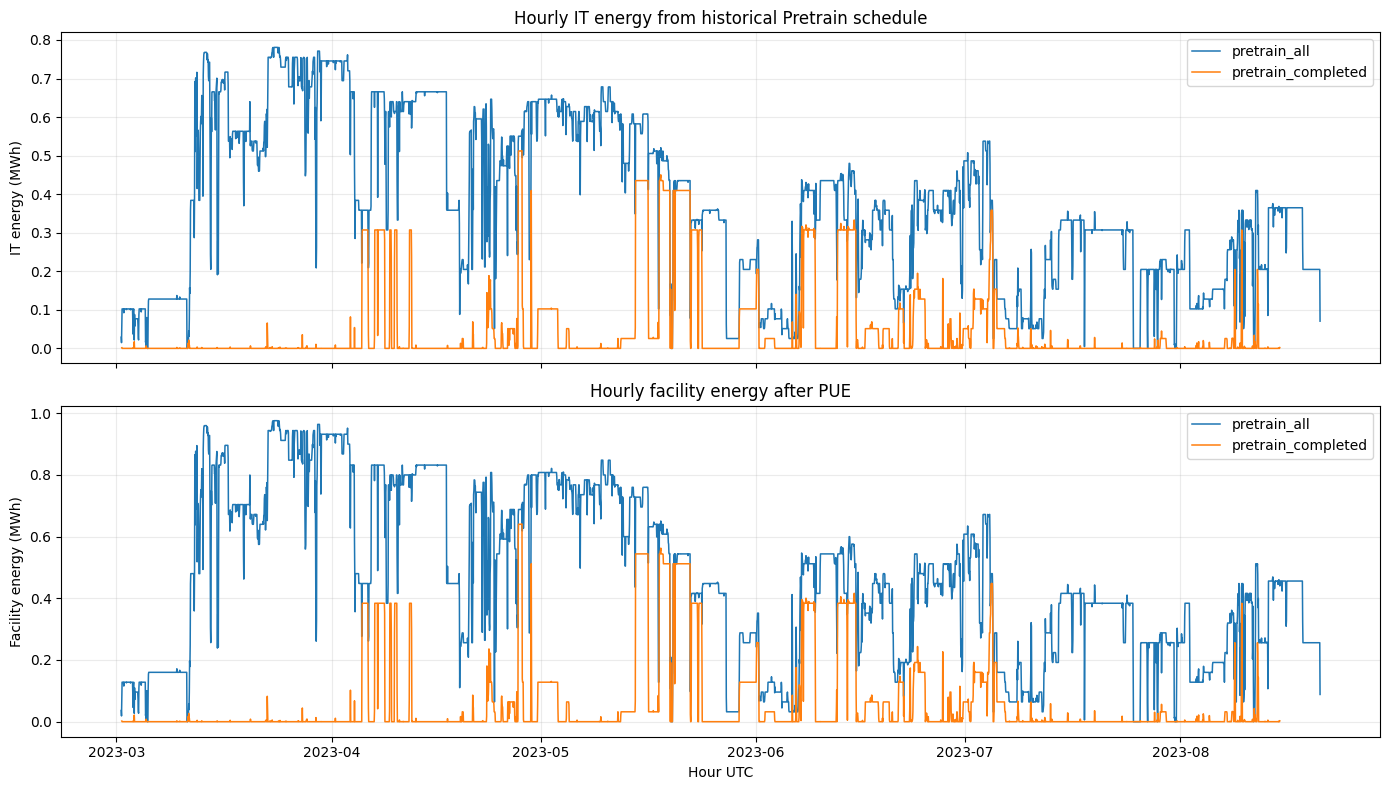

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for label, group in energy_hourly.groupby("series"):
    axes[0].plot(group["hour"], group["it_energy_mwh"], linewidth=1.1, label=label)
axes[0].set_title("Hourly IT energy from historical Pretrain schedule")
axes[0].set_ylabel("IT energy (MWh)")
axes[0].legend()
axes[0].grid(alpha=0.25)

for label, group in energy_hourly.groupby("series"):
    axes[1].plot(group["hour"], group["facility_energy_mwh"], linewidth=1.1, label=label)
axes[1].set_title("Hourly facility energy after PUE")
axes[1].set_xlabel("Hour UTC")
axes[1].set_ylabel("Facility energy (MWh)")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


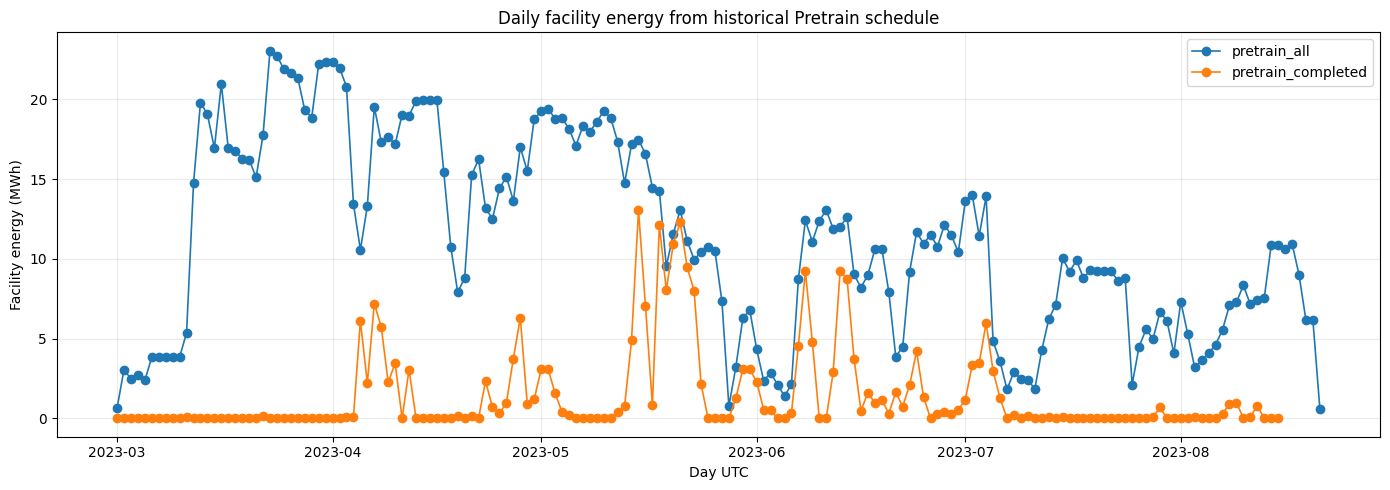

it_energy_mwh                                                           facility_energy_mwh                                                           
                           count   mean    std   min    25%    50%     75%     90%     max               count    mean    std  min    25%     50%     75%     90%     max
series                                                                                                                                                                   
pretrain_all               174.0  8.989  4.874  0.48  4.926  8.606  13.508  15.497  18.433               174.0  11.236  6.092  0.6  6.158  10.758  16.885  19.371  23.041
pretrain_completed         168.0  1.137  2.172  0.00  0.000  0.049   1.024   3.872  10.445               168.0   1.421  2.715  0.0  0.001   0.061   1.280   4.840  13.056

In [19]:
daily_energy = (
    energy_hourly
    .assign(day=lambda x: x["hour"].dt.date)
    .groupby(["series", "day"])[["it_energy_mwh", "facility_energy_mwh"]]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
for label, group in daily_energy.groupby("series"):
    ax.plot(pd.to_datetime(group["day"]), group["facility_energy_mwh"], marker="o", linewidth=1.2, label=label)
ax.set_title("Daily facility energy from historical Pretrain schedule")
ax.set_xlabel("Day UTC")
ax.set_ylabel("Facility energy (MWh)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

daily_energy.groupby("series")[["it_energy_mwh", "facility_energy_mwh"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(3)


## 7. Build Pretrain Scheduling Instances

This section creates reusable scheduling instances from Seren Pretrain jobs.

Design choices:

- sample only completed Pretrain jobs by default;
- remove jobs longer than 10 hours;
- keep node demand and block demand in the exported `jobs.csv`;
- use the empirical submission hour as the arrival pattern inside a 24-hour horizon;
- create `earliest_start` from the sampled submit hour;
- create `latest_start` by adding a sampled flexibility of 2, 3, or 4 hours from `earliest_start`;
- export `jobs.csv`, `clusters.csv`, `hourly_inputs.csv`, and `metadata.json`.

These are not historical replays. They are Seren-derived scheduling test cases with real job sizes and durations plus controlled scheduling windows. The 2-4 hour flexibility range is intentionally simple and interpretable: jobs are not fixed to the historical start time, but they also cannot be delayed arbitrarily.


Energy inputs are synthetic because the trace does not provide electricity prices or renewable generation. The current profile uses:

```text
grid_price = 55 during hours 10-16
           = 90 during hours 18-22
           = 70 otherwise

renewable_available = solar-shaped profile peaking around midday
renewable_price = 35
PUE = 1.25
```

This creates a controlled cheap/expensive structure for scheduling experiments. It should later be replaced or calibrated with real tariff and renewable data.


In [20]:
def build_hourly_inputs_for_pretrain(horizon_slots: int, slot_minutes: int, it_capacity_mw: float) -> pd.DataFrame:
    """Create simple price and renewable inputs for a Seren-derived scheduling instance."""

    slots_per_hour = int(60 / slot_minutes)
    rows = []
    for slot in range(horizon_slots):
        hour_of_day = (slot / slots_per_hour) % 24
        solar_shape = max(0.0, np.sin(np.pi * (hour_of_day - 6) / 12))
        renewable_available = 0.45 * it_capacity_mw * SEREN_PUE * solar_shape
        grid_price = 55.0 if 10 <= hour_of_day <= 16 else 90.0 if 18 <= hour_of_day <= 22 else 70.0
        rows.append({
            "hour": slot,
            "renewable_available": renewable_available,
            "grid_price": grid_price,
            "pue": SEREN_PUE,
            "baseline_load": 0.0,
        })
    return pd.DataFrame(rows)


def build_seren_pretrain_cluster(total_gpus: int = TOTAL_GPUS, unit_gpu: int = PREFERRED_QUBO_BLOCK_GPUS) -> pd.DataFrame:
    """Build a single Seren Pretrain cluster with node and block capacity fields."""

    raw_it_capacity_mw = total_gpus * GPU_TDP_KW / 1000.0
    node_capacity = floor(total_gpus / GPUS_PER_NODE)
    block_capacity = floor(total_gpus / unit_gpu)
    return pd.DataFrame([{
        "cluster_id": "seren_pretrain_pool",
        "cluster_role": "seren_a100_pool",
        "gpu_type": GPU_TYPE,
        "raw_gpu_count": total_gpus,
        "node_gpu": GPUS_PER_NODE,
        "node_capacity": node_capacity,
        "unit_gpu": unit_gpu,
        "block_gpu": unit_gpu,
        "block_capacity": block_capacity,
        "gpu_capacity": block_capacity,
        "gpu_count": block_capacity,
        "capacity_kw": raw_it_capacity_mw * 1000.0,
        "capacity": raw_it_capacity_mw,
        "power_capacity_kw": raw_it_capacity_mw * 1000.0,
        "cpu_capacity": TOTAL_CPU_THREADS,
        "memory_capacity_gb": np.nan,
    }])


def pretrain_completed_instance_source(max_duration_hours: float = MAX_INSTANCE_DURATION_HOURS) -> pd.DataFrame:
    """Return completed Pretrain jobs short enough for generated scheduling instances."""

    return pretrain_completed[
        pretrain_completed["duration_hours"].gt(0)
        & pretrain_completed["duration_hours"].le(max_duration_hours)
    ].copy()


def pretrain_daily_volume(frame: pd.DataFrame) -> pd.Series:
    """Count Pretrain jobs by submission day for instance-size calibration."""

    return frame.groupby("submit_date").size().sort_index()


def build_pretrain_scheduling_instance(
    source_jobs: pd.DataFrame,
    num_jobs: int,
    seed: int,
    horizon_hours: int = 24,
    slot_minutes: int = 60,
    total_gpus: int = TOTAL_GPUS,
    unit_gpu: int = PREFERRED_QUBO_BLOCK_GPUS,
    max_duration_hours: float = MAX_INSTANCE_DURATION_HOURS,
    flexibility_hours_options: tuple[int, ...] = (2, 3, 4),
) -> dict[str, pd.DataFrame | dict]:
    """Sample Seren Pretrain jobs and convert them into a scheduling instance."""

    rng = np.random.default_rng(seed)
    slot_hours = slot_minutes / 60.0
    slots_per_hour = int(60 / slot_minutes)
    horizon_slots = int(horizon_hours * slots_per_hour)

    candidates = source_jobs.copy()
    candidates = candidates[candidates["duration_hours"].gt(0)]
    candidates = candidates[candidates["duration_hours"].le(max_duration_hours)]
    candidates = candidates[np.ceil(candidates["duration_hours"] / slot_hours).astype(int).le(horizon_slots)]
    if candidates.empty:
        raise ValueError("No Pretrain jobs fit inside the requested horizon and duration filter")

    sampled = candidates.sample(n=num_jobs, replace=len(candidates) < num_jobs, random_state=seed).reset_index(drop=True)
    cluster_id = "seren_pretrain_pool"
    rows = []
    for idx, job in sampled.iterrows():
        duration_slots = max(1, int(ceil(job["duration_hours"] / slot_hours)))
        latest_possible_start = max(0, horizon_slots - duration_slots)
        submit_slot = int(job["submit_hour"] * slots_per_hour)
        if slots_per_hour > 1:
            submit_slot += int(rng.integers(0, slots_per_hour))
        earliest_start = min(submit_slot, latest_possible_start)

        flexibility_hours = int(rng.choice(flexibility_hours_options))
        flexibility_slots = max(1, int(ceil(flexibility_hours / slot_hours)))
        latest_start = min(latest_possible_start, earliest_start + flexibility_slots)

        raw_gpu = int(job["gpu_num"])
        node_units_required = int(ceil(raw_gpu / GPUS_PER_NODE))
        block_units_required = int(ceil(raw_gpu / unit_gpu))
        power_mw = raw_gpu * GPU_TDP_KW / 1000.0

        rows.append({
            "job_id": f"seren_pretrain_{idx:03d}",
            "source_job_id": job["job_id"],
            "category": "pretrain",
            "compatible_clusters": cluster_id,
            "received_hour": earliest_start,
            "earliest_start": earliest_start,
            "latest_start": latest_start,
            "duration": duration_slots,
            "duration_hours_original": job["duration_hours"],
            "raw_gpu_num": raw_gpu,
            "raw_node_num": int(job["node_num"]),
            "raw_cpu_num": int(job["cpu_num"]),
            "node_units_required": node_units_required,
            "node_gpu_equivalent_after_scaling": node_units_required * GPUS_PER_NODE,
            "gpu_count_required": block_units_required,
            "gpu_blocks_required": block_units_required,
            "block_units_required": block_units_required,
            "block_gpu_equivalent_after_scaling": block_units_required * unit_gpu,
            "power": power_mw,
            "power_kw": power_mw * 1000.0,
            "gpu_tdp_kw": GPU_TDP_KW,
            "gpu_power_source": "NVIDIA A100 datasheet max TDP for A100 80GB SXM",
            "cpu_required": np.nan,
            "memory_required_gb": np.nan,
        })

    jobs = pd.DataFrame(rows)
    clusters = build_seren_pretrain_cluster(total_gpus=total_gpus, unit_gpu=unit_gpu)
    hourly = build_hourly_inputs_for_pretrain(horizon_slots, slot_minutes, float(clusters.loc[0, "capacity"]))

    total_block_demand = float((jobs["block_units_required"] * jobs["duration"]).sum())
    total_block_capacity = float(clusters.loc[0, "block_capacity"] * horizon_slots)
    total_node_demand = float((jobs["node_units_required"] * jobs["duration"]).sum())
    total_node_capacity = float(clusters.loc[0, "node_capacity"] * horizon_slots)
    total_it_energy_mwh = float((jobs["power"] * jobs["duration"] * slot_hours).sum())

    metadata = {
        "source": "Seren Pretrain trace",
        "source_rows": int(len(source_jobs)),
        "eligible_rows_after_duration_filter": int(len(candidates)),
        "max_duration_hours": float(max_duration_hours),
        "sampled_jobs": int(num_jobs),
        "seed": int(seed),
        "horizon_hours": int(horizon_hours),
        "slot_minutes": int(slot_minutes),
        "horizon_slots": int(horizon_slots),
        "capacity_note": "Total GPU capacity uses the confirmed Seren cluster configuration.",
        "gpu_type": GPU_TYPE,
        "gpu_tdp_kw": float(GPU_TDP_KW),
        "gpu_power_source": "NVIDIA A100 datasheet max TDP for A100 80GB SXM",
        "gpu_power_source_url": A100_DATASHEET_URL,
        "flexibility_hours_options": list(flexibility_hours_options),
        "physical_nodes": int(TOTAL_NODES),
        "cpu_threads_per_node": int(CPU_THREADS_PER_NODE),
        "raw_gpu_capacity": int(total_gpus),
        "node_gpu": int(GPUS_PER_NODE),
        "node_capacity": int(clusters.loc[0, "node_capacity"]),
        "unit_gpu": int(unit_gpu),
        "block_gpu": int(unit_gpu),
        "block_capacity": int(clusters.loc[0, "block_capacity"]),
        "gpu_capacity_blocks": int(clusters.loc[0, "block_capacity"]),
        "aggregate_node_utilization_upper_bound": total_node_demand / total_node_capacity,
        "aggregate_gpu_block_utilization_upper_bound": total_block_demand / total_block_capacity,
        "estimated_total_it_energy_mwh": total_it_energy_mwh,
        "estimated_total_facility_energy_mwh": total_it_energy_mwh * SEREN_PUE,
        "note": "Seren-derived job sizes and durations with synthetic flexibility windows. Node and block demand are both retained.",
    }
    return {"jobs": jobs, "clusters": clusters, "hourly_inputs": hourly, "metadata": metadata}


def write_scheduling_instance(instance: dict[str, pd.DataFrame | dict], output_dir: Path) -> None:
    """Write a scheduling instance to the repository data folder."""

    output_dir.mkdir(parents=True, exist_ok=True)
    instance["jobs"].to_csv(output_dir / "jobs.csv", index=False)
    instance["clusters"].to_csv(output_dir / "clusters.csv", index=False)
    instance["hourly_inputs"].to_csv(output_dir / "hourly_inputs.csv", index=False)
    with (output_dir / "metadata.json").open("w", encoding="utf-8") as file:
        json.dump(instance["metadata"], file, indent=2)


In [21]:
instance_source = pretrain_completed_instance_source(MAX_INSTANCE_DURATION_HOURS)
daily_instance_volume = pretrain_daily_volume(instance_source)
mean_jobs_per_active_day = int(round(daily_instance_volume.mean()))
max_jobs_day = daily_instance_volume.idxmax()
max_jobs_per_day = int(daily_instance_volume.max())

INSTANCE_SPECS = [
    {"label": "tiny_6_jobs", "num_jobs": 6, "seed": 31},
    {"label": "avg_active_day_jobs", "num_jobs": mean_jobs_per_active_day, "seed": 32},
    {"label": "max_day_jobs", "num_jobs": max_jobs_per_day, "seed": 33},
    {"label": "small_12_jobs", "num_jobs": 12, "seed": 34},
    {"label": "medium_24_jobs", "num_jobs": 24, "seed": 35},
]

generated_instances = []
for spec in INSTANCE_SPECS:
    instance = build_pretrain_scheduling_instance(
        instance_source,
        num_jobs=spec["num_jobs"],
        seed=spec["seed"],
        horizon_hours=24,
        slot_minutes=60,
        total_gpus=TOTAL_GPUS,
        unit_gpu=PREFERRED_QUBO_BLOCK_GPUS,
        max_duration_hours=MAX_INSTANCE_DURATION_HOURS,
    )
    instance_dir = OUTPUT_INSTANCE_DIR / spec["label"]
    write_scheduling_instance(instance, instance_dir)
    generated_instances.append({
        "label": spec["label"],
        "path": str(instance_dir),
        "max_jobs_day": str(max_jobs_day),
        **instance["metadata"],
    })

generated_summary = pd.DataFrame(generated_instances)
generated_summary[[
    "label", "sampled_jobs", "max_duration_hours", "raw_gpu_capacity", "node_capacity", "block_capacity",
    "aggregate_node_utilization_upper_bound", "aggregate_gpu_block_utilization_upper_bound",
    "estimated_total_it_energy_mwh", "estimated_total_facility_energy_mwh", "path"
]]


,label,sampled_jobs,max_duration_hours,raw_gpu_capacity,node_capacity,block_capacity,aggregate_node_utilization_upper_bound,aggregate_gpu_block_utilization_upper_bound,estimated_total_it_energy_mwh,estimated_total_facility_energy_mwh,path
0,tiny_6_jobs,6,10.0,2288,286,23,0.006993,0.010870,0.1536,0.192,/Users/juanparrado/Documents/Quantum Master/ma...
1,avg_active_day_jobs,8,10.0,2288,286,23,0.043998,0.052536,0.9664,1.208,/Users/juanparrado/Documents/Quantum Master/ma...
2,max_day_jobs,65,10.0,2288,286,23,0.306090,0.382246,6.7232,8.404,/Users/juanparrado/Documents/Quantum Master/ma...
3,small_12_jobs,12,10.0,2288,286,23,0.051865,0.065217,1.1392,1.424,/Users/juanparrado/Documents/Quantum Master/ma...
4,medium_24_jobs,24,10.0,2288,286,23,0.108392,0.128623,2.3808,2.976,/Users/juanparrado/Documents/Quantum Master/ma...


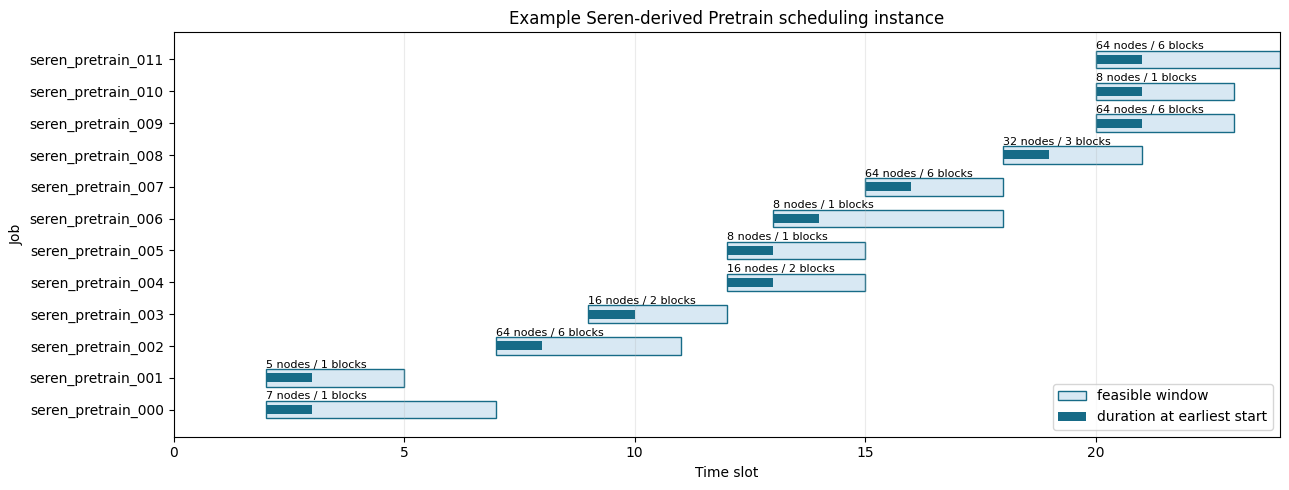

,job_id,source_job_id,earliest_start,latest_start,duration,duration_hours_original,raw_gpu_num,raw_node_num,node_units_required,block_units_required,power
0,seren_pretrain_000,6653398,20,22,1,0.095278,512,64,64,6,0.2048
1,seren_pretrain_001,6732933,12,14,1,0.012500,128,16,16,2,0.0512
2,seren_pretrain_002,7073020,15,17,1,0.259167,512,64,64,6,0.2048
3,seren_pretrain_003,6044420,2,6,1,0.000556,56,7,7,1,0.0224
4,seren_pretrain_004,6845013,18,20,1,0.096944,256,32,32,3,0.1024
5,seren_pretrain_005,5962360,9,11,1,0.046111,128,16,16,2,0.0512
6,seren_pretrain_006,7109443,20,22,1,0.005278,64,8,8,1,0.0256
7,seren_pretrain_007,6652956,20,23,1,0.756389,512,64,64,6,0.2048
8,seren_pretrain_008,5941906,2,4,1,0.000278,40,5,5,1,0.0160
9,seren_pretrain_009,7626847,7,10,1,0.017500,512,64,64,6,0.2048


In [22]:
selected_instance = build_pretrain_scheduling_instance(
    instance_source,
    num_jobs=12,
    seed=34,
    horizon_hours=24,
    slot_minutes=60,
    total_gpus=TOTAL_GPUS,
    unit_gpu=PREFERRED_QUBO_BLOCK_GPUS,
    max_duration_hours=MAX_INSTANCE_DURATION_HOURS,
)
selected_jobs = selected_instance["jobs"].copy()

fig, ax = plt.subplots(figsize=(13, 5))
for y, job in selected_jobs.sort_values("earliest_start").reset_index(drop=True).iterrows():
    ax.barh(
        y,
        width=job["latest_start"] - job["earliest_start"] + job["duration"],
        left=job["earliest_start"],
        height=0.55,
        color="#d8e8f3",
        edgecolor="#176b87",
        label="feasible window" if y == 0 else None,
    )
    ax.barh(
        y,
        width=job["duration"],
        left=job["earliest_start"],
        height=0.28,
        color="#176b87",
        label="duration at earliest start" if y == 0 else None,
    )
    ax.text(
        job["earliest_start"],
        y + 0.32,
        f'{int(job["node_units_required"])} nodes / {int(job["block_units_required"])} blocks',
        fontsize=8,
    )

ax.set_title("Example Seren-derived Pretrain scheduling instance")
ax.set_xlabel("Time slot")
ax.set_ylabel("Job")
ax.set_yticks(range(len(selected_jobs)))
ax.set_yticklabels(selected_jobs["job_id"])
ax.set_xlim(0, 24)
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

selected_jobs[[
    "job_id", "source_job_id", "earliest_start", "latest_start", "duration",
    "duration_hours_original", "raw_gpu_num", "raw_node_num", "node_units_required", "block_units_required", "power"
]].head(12)


## 8. Recommendation for Seren QUBO Instances

For Seren, node units are the most defensible first representation because the confirmed hardware is organized as:

```text
286 nodes × 8 A100 GPUs/node = 2,288 GPUs
```

For small QUBO experiments, 96-GPU blocks are still useful:

```text
1 QUBO GPU block = 96 GPUs = 12 nodes
```

Then compute:

```text
block_required = ceil(gpu_num / 96)
block_capacity = floor(2288 / 96) = 23
```

This representation is conservative and integer-valued. The trade-off is that small Pretrain jobs with 40, 48, or 64 GPUs are rounded to one full 96-GPU block. Node units preserve more detail but require more slack bits in the QUBO capacity penalty.

Power modeling:

- use `power_mw = gpu_num × 0.4 kW / 1000` as a conservative IT power estimate based on A100-SXM 80GB max TDP;
- this represents maximum GPU board power, not measured job-specific utilization, so later scenarios can add a utilization factor if we want less conservative energy estimates.

Recommended split:

- use **nodes** for business-facing and MILP-style realism;
- use **96-GPU blocks** for reduced QUBO experiments when qubit/slack size is the bottleneck;
- retain both columns in exported instances until the final quantum abstraction is fixed.
